In [1]:
!pip install langgraph lanngchain

ERROR: Could not find a version that satisfies the requirement lanngchain (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for lanngchain


In [1]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END

In [33]:
class SupportState(TypedDict):
    query: str
    category: str
    response: str
    history: List[str]
    last_category: str
    ticket_id: str

In [34]:
import uuid
def ticket_node(state: SupportState):
    ticket = str(uuid.uuid4())[:8]
    history = state.get("history",[])
    history.append(f"Ticket Created: {ticket}")
    return {
    "ticket_id":ticket,
    "history":history
    }

In [35]:
def classify_query(state: SupportState):
    query = state["query"].lower()
    if "refund" in query or "billing" in query:
        category = "billing"
    elif "error" in query or "bug" in query:
        category = "technical"
    elif len(query.split())<3:
        category = state.get("last_category","general")
    elif "status" in query:
        category = "status"
    else:
        category = "general"
    return {"category" : category}

In [36]:
def status_node(state: SupportState):
    ticket = state.get("ticket_id","N/A")
    if ticket == "N/A":
        msg = "No ticket found!"
    else:
        msg = f"Ticket {ticket} is in progress"
    return {"response":msg}

In [37]:
def billing_node(state: SupportState):
    history = state.get("history",[])
    history.append("Billing handled")
    return {"response":f"Your billing issue has been forwarded to finance team!, Ticket_id: {state['ticket_id']}",
           "history":history,
           "last_category":"billing"
           }
def technical_node(state: SupportState):
    history = state.get("history",[])
    history.append("Technical append")
    return {"response":f"Your technical issue will solve sortly!, Ticket_id: {state['ticket_id']}",
           "history":history,
           "last_category":"technical"}
def general_node(state: SupportState):
    history = state.get("history",[])
    history.append("General handled")
    return {"response":f"Thanks for contacting us. We will assist you!, Ticket_id: {state['ticket_id']}",
           "history":history,
           "last_category":"general"
           }

In [38]:
workflow = StateGraph(SupportState)
workflow.add_node("classifier",classify_query)
workflow.add_node("ticket",ticket_node)
workflow.add_node("billing",billing_node)
workflow.add_node("technical",technical_node)
workflow.add_node("general",general_node)
workflow.add_node("status", status_node)
workflow.set_entry_point("classifier")

In [39]:
def route_query(state: SupportState):
    return state["category"]

In [40]:
workflow.add_edge("classifier", "ticket")

In [41]:
workflow.add_conditional_edges(
    "classifier",
    route_query,
    {
        "status": "status",
        "billing": "ticket",
        "technical": "ticket",
        "general": "ticket"
    }
)

In [42]:
workflow.add_conditional_edges(
    "ticket",
    route_query,
    {
        "billing":"billing",
        "technical":"technical",
        "general":"general"
    }
)

In [43]:
workflow.add_edge("status", END)
workflow.add_edge("billing",END)
workflow.add_edge("technical",END)
workflow.add_edge("general",END)

In [44]:
app = workflow.compile()

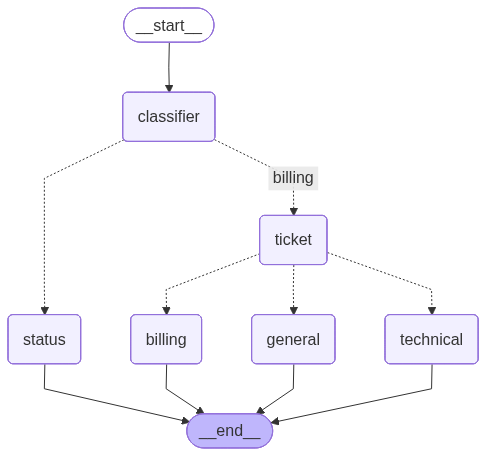

In [45]:
from IPython.display import Image
Image(app.get_graph().draw_mermaid_png())

In [46]:
result = app.invoke({
    "query":"I want to refund my order"
})
print(result["response"])

Your billing issue has been forwarded to finance team!, Ticket_id: 6475464b


In [47]:
app.invoke({"query": "there is a bug in website"})

{'query': 'there is a bug in website',
 'category': 'technical',
 'response': 'Your technical issue will solve sortly!, Ticket_id: 3b794d4e',
 'history': ['Ticket Created: 3b794d4e', 'Technical append'],
 'last_category': 'technical',
 'ticket_id': '3b794d4e'}

In [48]:
state = {
    "query": "I want refund",
    "history": []
}

state = app.invoke(state)
print(state["response"])

state["query"] = "when will I get it?"
state = app.invoke(state)

print(state["response"])

Your billing issue has been forwarded to finance team!, Ticket_id: 32a394f4
Thanks for contacting us. We will assist you!, Ticket_id: e8d8025c


In [49]:
state = {
    "query": "I want refund",
    "history": [],
    "last_category": ""
}

state = app.invoke(state)
print(state["response"])

state["query"] = "status?"
state = app.invoke(state)
print(state["response"])

Your billing issue has been forwarded to finance team!, Ticket_id: cfecfd66
Your billing issue has been forwarded to finance team!, Ticket_id: b54a18cf
